In [ ]:
"""
Yifu

Time: timewvr

purpose: To read text files and plot the 
    4 combinations of data which including TSRC0 TSRC1 TSRC2 TSRC3 EL AZ

"""

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datetime import datetime
import glob 
from matplotlib.ticker import MaxNLocator

new_f = []

with open('20240612_190135_scanAz_slow.txt', 'r') as f:
    # Read the file line by line
    for line in f:
        if line.startswith('#'):
            continue
        split_rows = line.split()
        new_f.append(split_rows)

df = pd.DataFrame(new_f)

#plot
fig, axs = plt.subplots(figsize=(30, 15), nrows=4 )

timewvr = df[1][1:].astype(float)

axs[3].scatter(df.index[1:], timewvr, label='TIMEWVR', s=0.2)
axs[3].set_title('TIMEWVR')
axs[3].yaxis.set_major_locator(MaxNLocator(nbins=10))

T0 = df[19][1:].astype(float)
T1 = df[20][1:].astype(float)
T2 = df[21][1:].astype(float)
T3 = df[22][1:].astype(float)

T0_25 = np.percentile(T0, 25)
T0_50 = np.percentile(T0, 50)
T0_75 = np.percentile(T0, 75)
T0_ave = np.mean(T0)
T0_std = np.std(T0)
T0_max = np.max(T0)
T0_min = np.min(T0)

# print(f"TSRC0 - 25th percentile: {T0_25}")
# print(f"TSRC0 - 50th percentile: {T0_50}")
# print(f"TSRC0 - 75th percentile: {T0_75}")
# print(f"TSRC0 - average: {T0_ave}")
# print(f"TSRC0 - std deviation: {T0_std}")
# print(f"TSRC0 - max: {T0_max}")
# print(f"TSRC0 - min: {T0_min}")

axs[0].scatter(df.index[1:], T0, label='TSRC0', color='orange', s=0.2)
axs[0].scatter(df.index[1:], T1, label='TSRC1', color='blue', s=0.2)
axs[0].scatter(df.index[1:], T2, label='TSRC2', color='green', s=0.2)
axs[0].scatter(df.index[1:], T3, label='TSRC3', color='red', s=0.2)
axs[0].set_title('TSRC0, TSRC1, TSRC2, TSRC3')
axs[0].yaxis.set_major_locator(MaxNLocator(nbins=15))
axs[0].legend()

El = df[23][1:].astype(float)

axs[2].scatter(df.index[1:], El, label='EL', s=0.2)
axs[2].set_title('EL')
axs[2].set_yscale('symlog')
#axs[2].yaxis.set_major_locator(MaxNLocator(nbins=3))

AZ = df[24][1:].astype(float)

axs[1].scatter(df.index[1:], AZ, label='AZ', s=0.2)
axs[1].set_title('AZ')
axs[1].yaxis.set_major_locator(MaxNLocator(nbins=10))

#create vertical line for every 315 index
for i in range(315, len(df), 315):
    axs[0].axvline(x=i, color='r', linestyle='--')
    axs[1].axvline(x=i, color='r', linestyle='--')
    axs[2].axvline(x=i, color='r', linestyle='--')
    axs[3].axvline(x=i, color='r', linestyle='--')

plt.show()
fig.savefig('scanAz_slow_timewvr.png', dpi=400)
plt.close()

In [ ]:
"""
Yifu

Time: datetime

purpose: To read text files and plot the 
    4 combinations of data which including TSRC0 TSRC1 TSRC2 TSRC3 EL AZ

"""

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datetime import datetime
import glob 
from matplotlib.ticker import MaxNLocator
import matplotlib.dates as mdates

new_f = []

with open('20240612_190135_scanAz_slow.txt', 'r') as f:
    # Read the file line by line
    for line in f:
        if line.startswith('#'):
            continue
        split_rows = line.split()
        new_f.append(split_rows)

df = pd.DataFrame(new_f)

#plot
fig, axs = plt.subplots(figsize=(30, 15), nrows=4 )

time = df[0]
for i in range(1, len(time)):
    time[i] = time[i].replace('T', ' ')
    
time_datetime = pd.to_datetime(time[1:], format='%Y-%m-%d %H:%M:%S.%f')
print(time_datetime[-2:-1])
axs[3].scatter(df.index[1:], time_datetime, label='TIME', s=0.2)
axs[3].set_title('TIME')
#axs[3].yaxis.set_major_locator(MaxNLocator(nbins=10))
date_format = mdates.DateFormatter('%Y-%m-%d %H:%M:%S')
axs[3].yaxis.set_major_formatter(date_format)
plt.setp(axs[3].get_yticklabels(), rotation=20, fontsize=6)

T0 = df[19][1:].astype(float)
T1 = df[20][1:].astype(float)
T2 = df[21][1:].astype(float)
T3 = df[22][1:].astype(float)

T0_25 = np.percentile(T0, 25)
T0_50 = np.percentile(T0, 50)
T0_75 = np.percentile(T0, 75)
T0_ave = np.mean(T0)
T0_std = np.std(T0)
T0_max = np.max(T0)
T0_min = np.min(T0)

# print(f"TSRC0 - 25th percentile: {T0_25}")
# print(f"TSRC0 - 50th percentile: {T0_50}")
# print(f"TSRC0 - 75th percentile: {T0_75}")
# print(f"TSRC0 - average: {T0_ave}")
# print(f"TSRC0 - std deviation: {T0_std}")
# print(f"TSRC0 - max: {T0_max}")
# print(f"TSRC0 - min: {T0_min}")

axs[0].scatter(df.index[1:], T0, label='TSRC0', color='orange', s=0.2)
axs[0].scatter(df.index[1:], T1, label='TSRC1', color='blue', s=0.2)
axs[0].scatter(df.index[1:], T2, label='TSRC2', color='green', s=0.2)
axs[0].scatter(df.index[1:], T3, label='TSRC3', color='red', s=0.2)
axs[0].set_title('TSRC0, TSRC1, TSRC2, TSRC3')
axs[0].yaxis.set_major_locator(MaxNLocator(nbins=15))
axs[0].legend()

El = df[23][1:].astype(float)

axs[2].scatter(df.index[1:], El, label='EL', s=0.2)
axs[2].set_title('EL')
axs[2].set_yscale('symlog')
#axs[2].set_xscale('symlog')
#axs[2].yaxis.set_major_locator(MaxNLocator(nbins=3))

AZ = df[24][1:].astype(float)

axs[1].scatter(df.index[1:], AZ, label='AZ', s=0.2)
axs[1].set_title('AZ')
axs[1].yaxis.set_major_locator(MaxNLocator(nbins=10))

#create vertical line for every 315 index
for i in range(315, len(df), 315):
    axs[0].axvline(x=i, color='r', linestyle='--')
    axs[1].axvline(x=i, color='r', linestyle='--')
    axs[2].axvline(x=i, color='r', linestyle='--')
    axs[3].axvline(x=i, color='r', linestyle='--')

plt.show()
fig.savefig('scanAz_slow_datetime.png', dpi=400)
plt.close()

In [ ]:
"""
Yifu

Use 5 subplots for EL : -9999.9999 AZ : -9999.9999

purpose: To read text files and plot the 
    4 combinations of data which including TSRC0 TSRC1 TSRC2 TSRC3 EL AZ
    Time: TIMEWVR
"""


import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datetime import datetime
import glob 
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import FuncFormatter

file_list = glob.glob("*scanAz_slow.txt")

for file in file_list:

    new_f = []

    with open(file, 'r') as f:
        # Read the file line by line
        for line in f:
            if line.startswith('#'):
                continue
            split_rows = line.split()
            new_f.append(split_rows)

    df = pd.DataFrame(new_f)

    timewvr = df[1][1:].astype(float)
    T0 = df[19][1:].astype(float)
    T1 = df[20][1:].astype(float)
    T2 = df[21][1:].astype(float)
    T3 = df[22][1:].astype(float)
    El = df[23][1:].astype(float)
    AZ = df[24][1:].astype(float)

    T0_ave = []
    T1_ave = []
    T2_ave = []
    T3_ave = []
    index_ave = []

    if El.min() == -9999.9999:

        fig, axs = plt.subplots(figsize=(30, 15), nrows=5 )
        fig.subplots_adjust(hspace=0.15, wspace=0.4)

        for ax in axs:
            ax.grid(True, linestyle='-', linewidth=0.2, alpha=0.3)

        for i in range(315, len(df), 315):
            axs[-1].axvline(x=i, color='r', linestyle='--')

        axs[2].scatter(df.index[1:], El, label='EL', s=0.2)
        axs[3].scatter(df.index[1:], El, label='EL', s=0.2)
        axs[2].set_ylim(50,60)
        axs[3].set_ylim((El.min()-10),(El.min()+10))
        axs[2].set_title('EL')

        axs[2].yaxis.set_major_locator(MaxNLocator(nbins=10))
        axs[3].yaxis.set_major_locator(MaxNLocator(nbins=10))
        
        axs[2].spines['bottom'].set_visible(False)
        axs[3].spines['top'].set_visible(False)
        axs[2].tick_params(labelbottom=False)  # Hide the x-axis tick labels on the top plot
        axs[3].xaxis.tick_bottom()
        axs[3].yaxis.tick_right()

        # Custom formatter to show full float values (not scientific notation)
        def float_formatter(x, pos):
            return f"{x:.1f}"

        axs[3].yaxis.set_major_formatter(FuncFormatter(float_formatter))
        plt.setp(axs[3].get_yticklabels(), rotation=20, fontsize=6)

        d = .004  # Size of the break lines
        # For top plot
        kwargs = dict(transform=axs[2].transAxes, color='k', clip_on=False)
        axs[2].plot((-d, +d), (-d, +d), **kwargs)        # Top-left diagonal
        axs[2].plot((1 - d, 1 + d), (-d, +d), **kwargs)  # Top-right diagonal
        # For bottom plot
        kwargs.update(transform=axs[3].transAxes)  # Switch to the bottom axes
        axs[3].plot((-d, +d), (1 - d, 1 + d), **kwargs)  # Bottom-left diagonal
        axs[3].plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)  # Bottom-right diagonal

    else:
        fig, axs = plt.subplots(figsize=(30, 15), nrows=4 )
        for ax in axs:
            ax.grid(True, linestyle='-', linewidth=0.2, alpha=0.3)
            
        axs[2].scatter(df.index[1:], El, label='EL', s=0.2)
        axs[2].set_title('EL')
        
        axs[2].yaxis.set_major_locator(MaxNLocator(nbins=3))


    axs[-1].scatter(df.index[1:], timewvr, label='TIMEWVR', s=0.2)
    axs[-1].set_title('TIMEWVR')
    axs[-1].yaxis.set_major_locator(MaxNLocator(nbins=10))

    axs[1].scatter(df.index[1:], AZ, label='AZ', s=0.2)
    axs[1].set_title('AZ')
    axs[1].yaxis.set_major_locator(MaxNLocator(nbins=10))

    #create vertical line for every 315 index
    for i in range(315, len(T0), 315):
        axs[0].axvline(x=i, color='r', linestyle='--')
        axs[1].axvline(x=i, color='r', linestyle='--')
        axs[2].axvline(x=i, color='r', linestyle='--')
        axs[3].axvline(x=i, color='r', linestyle='--')
        
        # plot the average for T0 T1 T2 T3
        T0_ave.append(np.mean(T0[i-315:i]))
        T1_ave.append(np.mean(T1[i-315:i]))
        T2_ave.append(np.mean(T2[i-315:i]))
        T3_ave.append(np.mean(T3[i-315:i]))
        index_ave.append(i-(315/2))

        if i+315 > len(T0):
            T0_ave.append(np.mean(T0[i:]))
            T1_ave.append(np.mean(T1[i:]))
            T2_ave.append(np.mean(T2[i:]))
            T3_ave.append(np.mean(T3[i:]))
            mid_index = (len(T0) - i)/2
            index_ave.append(i+mid_index)

    axs[0].scatter(df.index[1:], T0, label='TSRC0', color='orange', s=0.2)
    axs[0].scatter(df.index[1:], T1, label='TSRC1', color='blue', s=0.2)
    axs[0].scatter(df.index[1:], T2, label='TSRC2', color='green', s=0.2)
    axs[0].scatter(df.index[1:], T3, label='TSRC3', color='red', s=0.2)
    axs[0].set_title('TSRC0, TSRC1, TSRC2, TSRC3')

    axs[0].scatter(index_ave, T0_ave, label='T0_avg', color='tab:orange', s=400,marker='x')
    axs[0].scatter(index_ave, T1_ave, label='T1_avg', color='tab:blue', s=400, marker='x')
    axs[0].scatter(index_ave, T2_ave, label='T2_avg', color='tab:green', s=400, marker='x')
    axs[0].scatter(index_ave, T3_ave, label='T3_avg', color='tab:red', s=400, marker='x')

    axs[0].yaxis.set_major_locator(MaxNLocator(nbins=14))
    axs[0].legend()

    #plt.show()
    #break
    fig.savefig(f'breakEl_{file}.png', dpi=400)
    plt.close(fig)
    

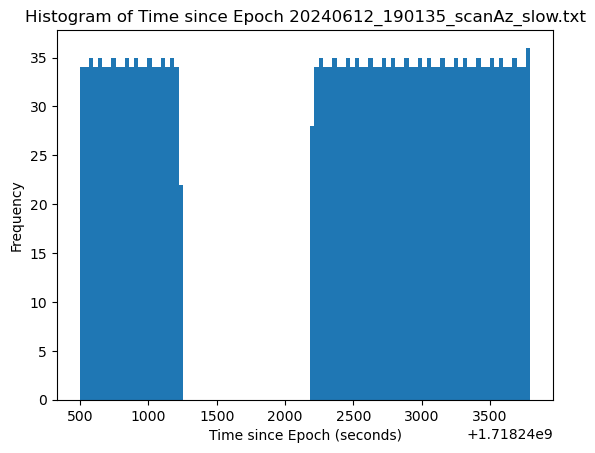

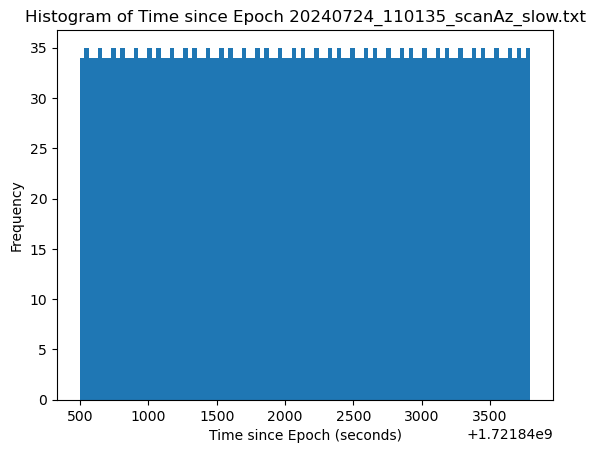

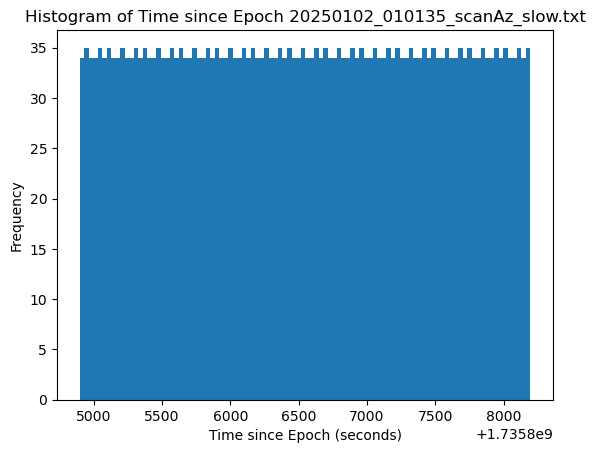

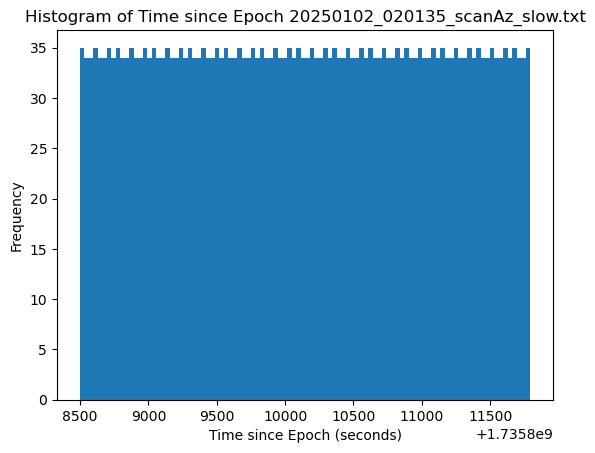

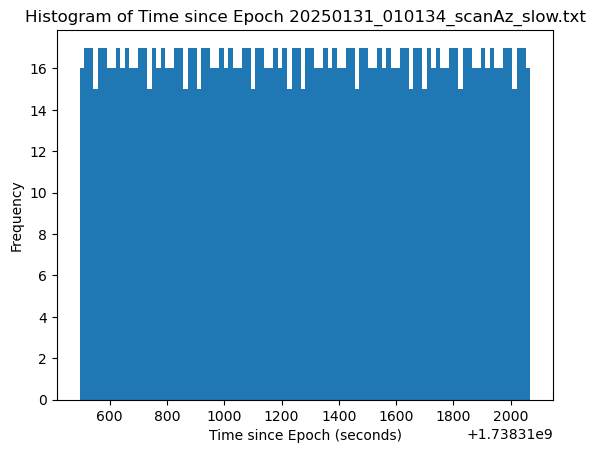

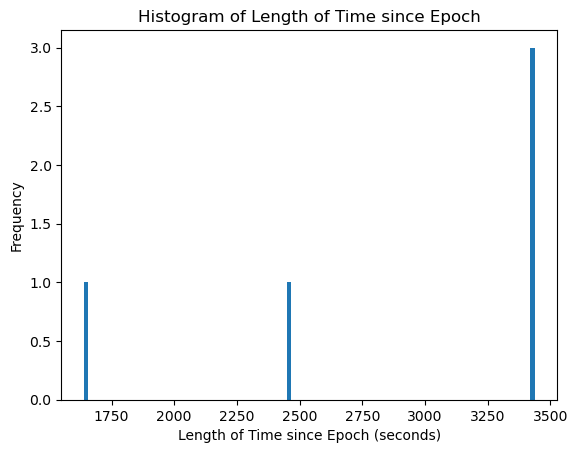

In [20]:
# read scanAZ files plot the line and leap time by plt.hist

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datetime import datetime
import glob 
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import FuncFormatter
import time as t_fun

# 20240612_190135_scanAz_slow for test including bad data
file_list = glob.glob("*_scanAz_slow.txt")
len_list = []
for file in file_list:

    new_f = []

    with open(file, 'r') as f:
        # Read the file line by line
        for line in f:
            if line.startswith('#'):
                continue
            split_rows = line.split()
            new_f.append(split_rows)

    df = pd.DataFrame(new_f)


    time = df[0][1:] #format: 2024-06-12T19:12:05.551599
    timewvr = df[1][1:].astype(float)
    T0 = df[19][1:].astype(float)
    T1 = df[20][1:].astype(float)
    T2 = df[21][1:].astype(float)
    T3 = df[22][1:].astype(float)
    El = df[23][1:].astype(float)
    AZ = df[24][1:].astype(float)

    #convert {time} in local time to seconds since the Epoch
    T_since_Epo = np.zeros(len(time))
    for i in range(1, len(time)+1):
        #time[i] = time[i].replace('T', ' ')
        #print(time[i])
        T_since_Epo[i-1] = t_fun.mktime(t_fun.strptime(time[i], "%Y-%m-%dT%H:%M:%S.%f"))

    #print(len(T_since_Epo))
    len_list.append(len(T_since_Epo))

    plt.hist(T_since_Epo, bins=100)
    plt.xlabel('Time since Epoch (seconds)')
    plt.ylabel('Frequency')
    plt.title(f'Histogram of Time since Epoch {file}')
    plt.savefig(f'hist/hist_time_since_epoch_{file}.png')
    plt.show()

plt.hist(len_list, bins=100)
plt.xlabel('Length of Time since Epoch (seconds)')
plt.ylabel('Frequency')
plt.title('Histogram of Length of Time since Epoch')
plt.savefig(f'hist/hist_length_of_time_since_epoch.png')
plt.show()

In [1]:
import time
t0 = time.time()
print(t0)
time_str = "1 Jan 2000 00:00:00"
t1 = time.mktime(time.strptime(time_str, "%d %b %Y %H:%M:%S"))
print(t1)

1755882796.638697
946710000.0
